**Prediction of Burnout in Remote Work Settings**

---


Group 9

In [1]:
#############################
#       IMPORT LIBRARIES    #
#############################

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

import os
# Github
repo_path = "data/wfh_burnout_dataset.csv"
# Google Colab
file_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/wfh_burnout_dataset.csv"

if os.path.exists(file_path):
  ds = pd.read_csv(file_path)
  print("Dataset loaded successfully.")
elif os.path.exists(repo_path):
  ds = pd.read_csv(repo_path)
  print("Dataset loaded successfully.")
else:
  raise FileNotFoundError("Dataset not found in Drive or repo.")
ds.head()

Dataset loaded successfully.


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [4]:
#############################
#   QUICK DATA INSPECTION   #
#############################

print(ds.shape)
print()
print(ds.info())
print()
ds.describe()

(2000, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB
None



,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,75.028000,8.955995,7.689495,3.728500,5.066000,0.15650,56.025500,6.894900,80.090670,4.875500,6.560825,35.656590
std,43.317138,1.724214,1.983181,2.874877,1.762441,0.36342,23.702463,0.983893,12.708583,1.656011,2.218042,17.315039
min,1.000000,4.730000,2.910000,0.000000,0.000000,0.00000,5.000000,3.580000,40.000000,3.000000,1.450000,6.060000
25%,37.000000,7.750000,6.280000,2.000000,4.000000,0.00000,39.000000,6.320000,71.672500,3.000000,4.740000,21.005000
50%,77.000000,8.535000,7.290000,3.000000,5.000000,0.00000,52.000000,7.080000,80.900000,5.000000,6.295000,32.330000
75%,112.000000,9.980000,8.882500,5.000000,6.000000,0.00000,71.000000,7.570000,89.650000,6.000000,8.480000,47.475000
max,150.000000,14.230000,13.980000,17.000000,11.000000,1.00000,152.000000,9.220000,100.000000,9.000000,10.000000,82.220000


In [5]:
#############################
#     CHECK MISSING DATA    #
#############################

ds.isnull().sum()

,0
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
app_switches,0
sleep_hours,0
task_completion,0


In [6]:
#############################
# BURNOUT RISK DISTRIBUTION #
#############################

ds["burnout_risk"].value_counts()

,count
burnout_risk,
Low,1019
Medium,843
High,138


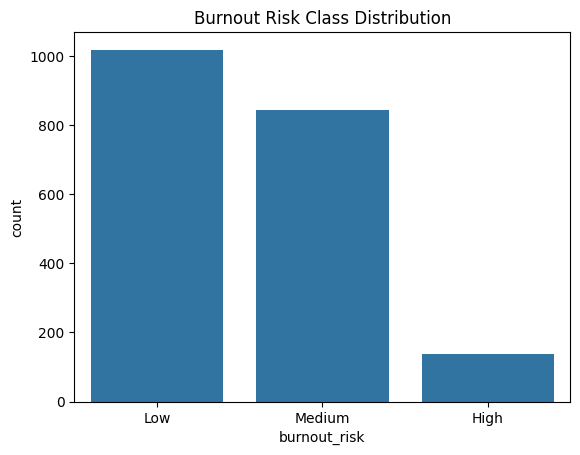

In [7]:
sns.countplot(x="burnout_risk", data=ds)
plt.title("Burnout Risk Class Distribution")
plt.show()

In [8]:
#############################
#   DAY TYPE DISTRIBUTION   #
#############################

ds["day_type"].value_counts()

,count
day_type,
Weekday,1435
Weekend,565


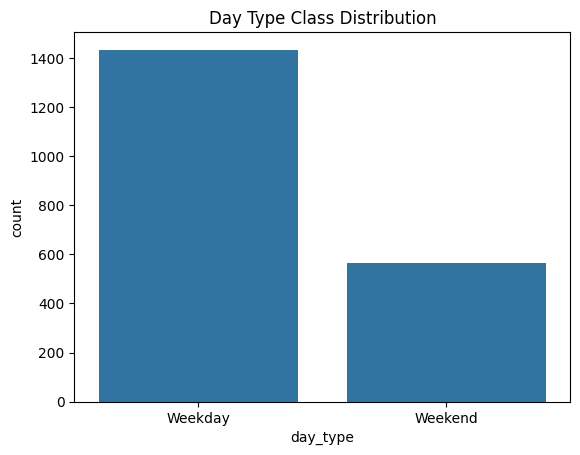

In [9]:
sns.countplot(x="day_type", data=ds)
plt.title("Day Type Class Distribution")
plt.show()

In [10]:
#############################
# DROP UNNECESSARY FEATURE  #
#############################

ds = ds.drop("user_id", axis=1)
# Changes
ds = ds.drop("burnout_score", axis=1)
ds.columns

Index(['day_type', 'work_hours', 'screen_time_hours', 'meetings_count',
       'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours',
       'task_completion', 'isolation_index', 'fatigue_score', 'burnout_risk'],
      dtype='object')

In [11]:
#############################
#  ENCODE TARGET VARIABLES  #
#############################

ds["burnout_risk"] = ds["burnout_risk"].map({"High": 2, "Medium": 1, "Low": 0})
ds["burnout_risk"].value_counts()

,count
burnout_risk,
0,1019
1,843
2,138


In [12]:
#############################
#  ENCODE DAY_TYPE COLUMN   #
#############################

ds = pd.get_dummies(ds, columns=["day_type"], drop_first=True)
ds.head()

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_risk,day_type_Weekend
0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,0,False
1,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,0,False
2,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,1,True
3,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,1,False
4,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,0,True


In [13]:
#############################
# SEPARATE FEATURES & TARGET#
#############################

X = ds.drop("burnout_risk", axis=1)
y = ds["burnout_risk"]

In [14]:
X.head()

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,day_type_Weekend
0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,False
1,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,False
2,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,True
3,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,False
4,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,True


In [15]:
y.head()

,burnout_risk
0,0
1,0
2,1
3,1
4,0


In [16]:
#############################
#     TRAIN / TEST SPLIT    #
#############################

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 11)
(400, 11)
(1600,)
(400,)


In [17]:
#############################
#      FEATURE SCALING      #
#############################

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1600, 11)
(400, 11)


In [18]:
#############################
#        SAVE DATA          #
#############################

import os

# Github
# path = "processed_data"
path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data"
os.makedirs(path, exist_ok=True)
X_train_scaled.to_csv(f"{path}/X_train_scaled.csv", index=False)
X_test_scaled.to_csv(f"{path}/X_test_scaled.csv", index=False)
y_train.to_csv(f"{path}/y_train.csv", index=False)
y_test.to_csv(f"{path}/y_test.csv", index=False)